# Notebook 05 — Modelado Multilabel RF / XGBoost

**Fase 3 · Módulo 3A** — Entrenamiento, evaluación y serialización del clasificador multilabel.

**Entrada:**  
- `data/processed/train.csv` (1.717 registros), `val.csv` (368), `test.csv` (369)  
- `feature_columns.json` (38 features canónicos), `label_columns.json`

**Salida:**  
- `models/best_model.pkl`, `models/rf_multilabel.pkl`, `models/xgb_multilabel.pkl`  
- `models/model_metadata.json`, `data/processed/decision_thresholds.json`  
- `outputs/shap_feature_importance.png`, `outputs/shap_global_importance.csv`

| Sección | Contenido |
|---|---|
| **0** | Dependencias y configuración |
| **1** | Carga y verificación de splits |
| **2** | Análisis de desbalance por etiqueta |
| **3** | Modelo A: Random Forest con balanceo por pesos de muestra |
| **4** | Modelo B: XGBoost con `scale_pos_weight` por etiqueta |
| **5** | Optimización de hiperparámetros (grid search sobre val) |
| **6** | Selección de umbrales de decisión por etiqueta (F1-maximizing) |
| **7** | Ablation study: `flag_lymphopenia` y `QC_REQUIERE_FROTIS` |
| **8** | Evaluación final en test: curvas PR y tabla de métricas con IC bootstrap |
| **9** | Análisis de errores (FP/FN) |
| **10** | Análisis SHAP e importancia global de features |
| **11–13** | Serialización, checklist de cierre y resumen |


### Guia rapida del codigo

- Carga `train.csv`, `val.csv` y `test.csv` desde `data/processed/`.
- Entrena Random Forest y XGBoost multilabel, luego compara resultados en validacion.
- Ajusta umbrales por etiqueta y evalua el modelo ganador en test.
- Guarda modelos, metricas, curvas, SHAP y metadatos en `models/` y `outputs/`.


## 0. Dependencias y configuracion

In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import warnings
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    f1_score, roc_auc_score, classification_report
)
from sklearn.model_selection import ParameterGrid
import xgboost as xgb
import shap
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"]    = 120
plt.rcParams["savefig.dpi"]   = 150
plt.rcParams["figure.figsize"] = (12, 6)

def save_and_show(fig, filename, outputs_dir=None):
    """Guarda la figura en disco y la muestra inline en el notebook."""
    if outputs_dir is None:
        outputs_dir = OUTPUTS
    path = outputs_dir / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))
    print(f"  [Guardada] {filename}")

# Rutas del proyecto
_cwd = Path.cwd()
PROJECT_ROOT = _cwd
while PROJECT_ROOT.name != "hemogramas-proyectoICC" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT.name != "hemogramas-proyectoICC":
    raise RuntimeError(f"No se localizo la raiz del proyecto. CWD: {_cwd}")

DATA_PROC = PROJECT_ROOT / "data" / "processed"
OUTPUTS   = PROJECT_ROOT / "outputs"
MODELS    = PROJECT_ROOT / "models"

for d in [DATA_PROC, OUTPUTS, MODELS]:
    d.mkdir(parents=True, exist_ok=True)

# Cargar artefactos de configuracion del NB04
with open(DATA_PROC / "feature_columns.json") as f:
    FC = json.load(f)
with open(DATA_PROC / "label_columns.json") as f:
    LC = json.load(f)
with open(DATA_PROC / "label_distribution.json") as f:
    LD = json.load(f)

FEATURES        = FC["feature_columns"]
OFFICIAL_LABELS = LC["official_labels"]
MARGINAL_LABELS = LC["marginal_labels"]

print(f"Raiz del proyecto    : {PROJECT_ROOT}")
print(f"Datos procesados     : {DATA_PROC}")
print(f"Features             : {len(FEATURES)}")
print(f"Etiquetas oficiales  : {len(OFFICIAL_LABELS)}")
print(f"Etiquetas marginales : {MARGINAL_LABELS}")

/home/edwinb/tesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raiz del proyecto    : /home/edwinb/tesis/hemogramas-proyectoICC
Datos procesados     : /home/edwinb/tesis/hemogramas-proyectoICC/data/processed
Features             : 38
Etiquetas oficiales  : 8
Etiquetas marginales : ['PATRON_POLICITEMIA', 'PATRON_ANEMIA_REGENERATIVA']


---
## 1. Carga y verificacion de splits

Cargamos los splits temporales del NB04 y verificamos las condiciones criticas
de integridad antes de entrenar. Si alguna verificacion falla, el notebook no
debe continuar.

In [2]:
df_train = pd.read_csv(DATA_PROC / "train.csv")
df_val   = pd.read_csv(DATA_PROC / "val.csv")
df_test  = pd.read_csv(DATA_PROC / "test.csv")

print(f"Train : {len(df_train):,} registros")
print(f"Val   : {len(df_val):,} registros")
print(f"Test  : {len(df_test):,} registros")

# VERIFICACION CRITICA 1: idexx_comments no esta en features
assert "idexx_comments" not in FEATURES, \
    "CRITICO: idexx_comments en el feature set -- leakage total"

# VERIFICACION CRITICA 2: todos los features existen en cada split
for split_name, df_split in [("train", df_train), ("val", df_val), ("test", df_test)]:
    missing = [f for f in FEATURES if f not in df_split.columns]
    assert len(missing) == 0, f"Features faltantes en {split_name}: {missing}"

# VERIFICACION CRITICA 3: todas las etiquetas existen
for split_name, df_split in [("train", df_train), ("val", df_val), ("test", df_test)]:
    missing = [l for l in OFFICIAL_LABELS if l not in df_split.columns]
    assert len(missing) == 0, f"Etiquetas faltantes en {split_name}: {missing}"

# Preparar matrices
X_train = df_train[FEATURES]
X_val   = df_val[FEATURES]
X_test  = df_test[FEATURES]

Y_train = df_train[OFFICIAL_LABELS].values
Y_val   = df_val[OFFICIAL_LABELS].values
Y_test  = df_test[OFFICIAL_LABELS].values

# VERIFICACION CRITICA 4: sin nulos en features
for name, X in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    n_null = X.isna().sum().sum()
    assert n_null == 0, f"Nulos en {name}: {n_null}"

print("\nVerificaciones de integridad: OK")

# Verificar rangos temporales (documentacion)
if "sample_date" in df_train.columns:
    print(f"\nTrain fechas: {df_train['sample_date'].min()} -> {df_train['sample_date'].max()}")
    print(f"Val   fechas: {df_val['sample_date'].min()} -> {df_val['sample_date'].max()}")
    print(f"Test  fechas: {df_test['sample_date'].min()} -> {df_test['sample_date'].max()}")

print(f"\nX_train: {X_train.shape} | Y_train: {Y_train.shape}")

Train : 1,717 registros
Val   : 368 registros
Test  : 369 registros

Verificaciones de integridad: OK

Train fechas: 2022-11-24 -> 2025-06-14
Val   fechas: 2025-06-14 -> 2025-10-24
Test  fechas: 2025-10-24 -> 2026-02-19

X_train: (1717, 38) | Y_train: (1717, 8)


---
## 2. Analisis de desbalance por etiqueta

El desbalance refleja la realidad clinica de la poblacion. No se aplica
oversampling (SMOTE) porque los registros sinteticos en datos clinicos tabulares
pueden introducir combinaciones de valores fisiologicamente imposibles.
Se usa `class_weight='balanced'` en RF y `scale_pos_weight` en XGBoost.

In [3]:
print("Desbalance por etiqueta en train:")
print()
print(f"{'Etiqueta':<42} {'Pos':>5} {'Neg':>5} {'Ratio':>7}  Estado")
print("-" * 75)

for i, label in enumerate(OFFICIAL_LABELS):
    pos = int(Y_train[:, i].sum())
    neg = len(Y_train) - pos
    ratio = neg / pos if pos > 0 else float("inf")
    test_n = LD[label]["test"]

    if label in MARGINAL_LABELS:
        estado = "MARGINAL"
    elif test_n < 15:
        estado = "BAJO"
    else:
        estado = "OK"

    print(f"  {label:<40} {pos:>5} {neg:>5} {ratio:>6.1f}:1  {estado}")

Desbalance por etiqueta en train:

Etiqueta                                     Pos   Neg   Ratio  Estado
---------------------------------------------------------------------------
  QC_REQUIERE_FROTIS                         601  1116    1.9:1  OK
  QC_AGREGADOS_PLAQUETARIOS                   95  1622   17.1:1  BAJO
  PATRON_INFLAMATORIO                        770   947    1.2:1  OK
  PATRON_LEUCOGRAMA_ESTRES                   769   948    1.2:1  OK
  PATRON_ANEMIA_NO_REGENERATIVA              163  1554    9.5:1  OK
  PATRON_HEMOLISIS_MCHC                      217  1500    6.9:1  OK
  PATRON_POLICITEMIA                         109  1608   14.8:1  MARGINAL
  PATRON_ANEMIA_REGENERATIVA                  87  1630   18.7:1  MARGINAL


---
## 3. Modelo A -- Random Forest con balanceo

### 3.1 Pesos de muestra para multilabel

In [4]:
def compute_sample_weights_multilabel(Y):
    """
    Calcula pesos de muestra para el caso multilabel.
    Cada registro recibe el peso maximo entre sus etiquetas activas.
    Registros negativos en todas las etiquetas reciben peso 1.0.
    """
    n_samples, n_labels = Y.shape
    weights = np.ones(n_samples)

    for j in range(n_labels):
        pos = Y[:, j].sum()
        neg = n_samples - pos
        if pos > 0:
            w_pos = neg / pos
            mask_pos = Y[:, j] == 1
            weights[mask_pos] = np.maximum(weights[mask_pos], w_pos)

    return weights

sample_weights = compute_sample_weights_multilabel(Y_train)
print(f"Peso minimo   : {sample_weights.min():.2f}")
print(f"Peso maximo   : {sample_weights.max():.2f}")
print(f"Peso promedio : {sample_weights.mean():.2f}")

Peso minimo   : 1.00
Peso maximo   : 18.74
Peso promedio : 4.91


### 3.2 Entrenamiento Random Forest

In [5]:
RF_PARAMS = {
    "n_estimators"    : 300,
    "max_depth"       : None,
    "min_samples_leaf": 5,
    "max_features"    : "sqrt",
    "class_weight"    : "balanced_subsample",
    "n_jobs"          : -1,
    "random_state"    : 42,
}

# RF nativo multilabel (soporta multi-output directo)
rf_model = RandomForestClassifier(**RF_PARAMS)
rf_model.fit(X_train, Y_train, sample_weight=sample_weights)

print("Random Forest entrenado.")
print(f"  n_estimators    : {rf_model.n_estimators}")
print(f"  max_depth       : {rf_model.max_depth}")
print(f"  min_samples_leaf: {rf_model.min_samples_leaf}")

Random Forest entrenado.
  n_estimators    : 300
  max_depth       : None
  min_samples_leaf: 5


### 3.3 Evaluacion en validacion

In [6]:
def evaluate_multilabel(model, X, Y_true, label_names, split_name="Val",
                        label_dist=None, marginal_labels=None,
                        xgb_models=None):
    """
    Evalua un modelo multilabel con PR-AUC, ROC-AUC y F1 por etiqueta.
    Usa umbral de 0.5 como baseline.

    Para XGBoost, pasar xgb_models (dict) en lugar de model.
    """
    if xgb_models is not None:
        Y_prob_matrix = np.column_stack([
            xgb_models[label].predict_proba(X)[:, 1]
            for label in label_names
        ])
    else:
        Y_prob = model.predict_proba(X)
        if isinstance(Y_prob, list):
            Y_prob_matrix = np.column_stack([p[:, 1] for p in Y_prob])
        else:
            Y_prob_matrix = Y_prob

    Y_pred = (Y_prob_matrix >= 0.5).astype(int)

    print(f"\n{'='*70}")
    print(f"  EVALUACION -- {split_name}")
    print(f"{'='*70}")
    print(f"{'Etiqueta':<42} {'PR-AUC':>7} {'ROC-AUC':>8} {'F1@0.5':>7}")
    print("-" * 70)

    results = {}
    for i, label in enumerate(label_names):
        y_true = Y_true[:, i]
        y_prob = Y_prob_matrix[:, i]
        y_pred = Y_pred[:, i]

        if y_true.sum() == 0:
            print(f"  {label:<40} {'N/A':>7} {'N/A':>8} {'N/A':>7}  sin positivos")
            continue

        pr_auc  = average_precision_score(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)
        f1      = f1_score(y_true, y_pred, zero_division=0)

        warn = ""
        if marginal_labels and label in marginal_labels:
            warn = " *MARGINAL"

        print(f"  {label:<40} {pr_auc:>7.3f} {roc_auc:>8.3f} {f1:>7.3f}{warn}")

        results[label] = {
            "pr_auc": pr_auc, "roc_auc": roc_auc,
            "f1_05": f1, "n_positive": int(y_true.sum())
        }

    return results, Y_prob_matrix

rf_val_results, rf_val_probs = evaluate_multilabel(
    rf_model, X_val, Y_val, OFFICIAL_LABELS,
    split_name="Val (RF baseline)",
    marginal_labels=MARGINAL_LABELS
)


  EVALUACION -- Val (RF baseline)
Etiqueta                                    PR-AUC  ROC-AUC  F1@0.5
----------------------------------------------------------------------
  QC_REQUIERE_FROTIS                         0.876    0.904   0.782
  QC_AGREGADOS_PLAQUETARIOS                  0.120    0.723   0.100
  PATRON_INFLAMATORIO                        0.988    0.991   0.971
  PATRON_LEUCOGRAMA_ESTRES                   0.970    0.973   0.881
  PATRON_ANEMIA_NO_REGENERATIVA              0.714    0.941   0.535
  PATRON_HEMOLISIS_MCHC                      0.972    0.985   0.949
  PATRON_POLICITEMIA                         1.000    1.000   1.000 *MARGINAL
  PATRON_ANEMIA_REGENERATIVA                 0.432    0.965   0.474 *MARGINAL


---
## 4. Modelo B -- XGBoost con balanceo

XGBoost no soporta multilabel nativo. Se entrena un clasificador independiente
por etiqueta con `scale_pos_weight` ajustado al ratio de desbalance.

In [7]:
def get_scale_pos_weight(Y, label_idx):
    """scale_pos_weight = n_negativos / n_positivos para XGBoost."""
    pos = Y[:, label_idx].sum()
    neg = len(Y) - pos
    return neg / pos if pos > 0 else 1.0

XGB_BASE_PARAMS = {
    "n_estimators"     : 300,
    "max_depth"        : 6,
    "learning_rate"    : 0.05,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "min_child_weight" : 5,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 1.0,
    "random_state"     : 42,
    "eval_metric"      : "aucpr",
    "verbosity"        : 0,
}

xgb_models = {}

print("Entrenando XGBoost por etiqueta...")
for i, label in enumerate(OFFICIAL_LABELS):
    spw = get_scale_pos_weight(Y_train, i)

    xgb_clf = xgb.XGBClassifier(
        **XGB_BASE_PARAMS,
        scale_pos_weight=spw,
    )

    xgb_clf.fit(
        X_train, Y_train[:, i],
        eval_set=[(X_val, Y_val[:, i])],
        verbose=False,
    )

    xgb_models[label] = xgb_clf
    print(f"  {label:<42} spw={spw:.1f}")

print(f"\nXGBoost entrenado ({len(xgb_models)} modelos independientes).")

Entrenando XGBoost por etiqueta...
  QC_REQUIERE_FROTIS                         spw=1.9
  QC_AGREGADOS_PLAQUETARIOS                  spw=17.1
  PATRON_INFLAMATORIO                        spw=1.2
  PATRON_LEUCOGRAMA_ESTRES                   spw=1.2
  PATRON_ANEMIA_NO_REGENERATIVA              spw=9.5
  PATRON_HEMOLISIS_MCHC                      spw=6.9
  PATRON_POLICITEMIA                         spw=14.8
  PATRON_ANEMIA_REGENERATIVA                 spw=18.7

XGBoost entrenado (8 modelos independientes).


### 4.1 Evaluacion XGBoost en validacion

In [8]:
xgb_val_results, xgb_val_probs = evaluate_multilabel(
    None, X_val, Y_val, OFFICIAL_LABELS,
    split_name="Val (XGB baseline)",
    marginal_labels=MARGINAL_LABELS,
    xgb_models=xgb_models
)


  EVALUACION -- Val (XGB baseline)
Etiqueta                                    PR-AUC  ROC-AUC  F1@0.5
----------------------------------------------------------------------
  QC_REQUIERE_FROTIS                         0.915    0.929   0.818
  QC_AGREGADOS_PLAQUETARIOS                  0.192    0.782   0.100
  PATRON_INFLAMATORIO                        0.985    0.987   0.974
  PATRON_LEUCOGRAMA_ESTRES                   0.981    0.981   0.922
  PATRON_ANEMIA_NO_REGENERATIVA              0.753    0.969   0.714
  PATRON_HEMOLISIS_MCHC                      0.982    0.988   0.956
  PATRON_POLICITEMIA                         1.000    1.000   1.000 *MARGINAL
  PATRON_ANEMIA_REGENERATIVA                 0.514    0.957   0.526 *MARGINAL


### 4.2 Comparacion RF vs XGBoost en validacion

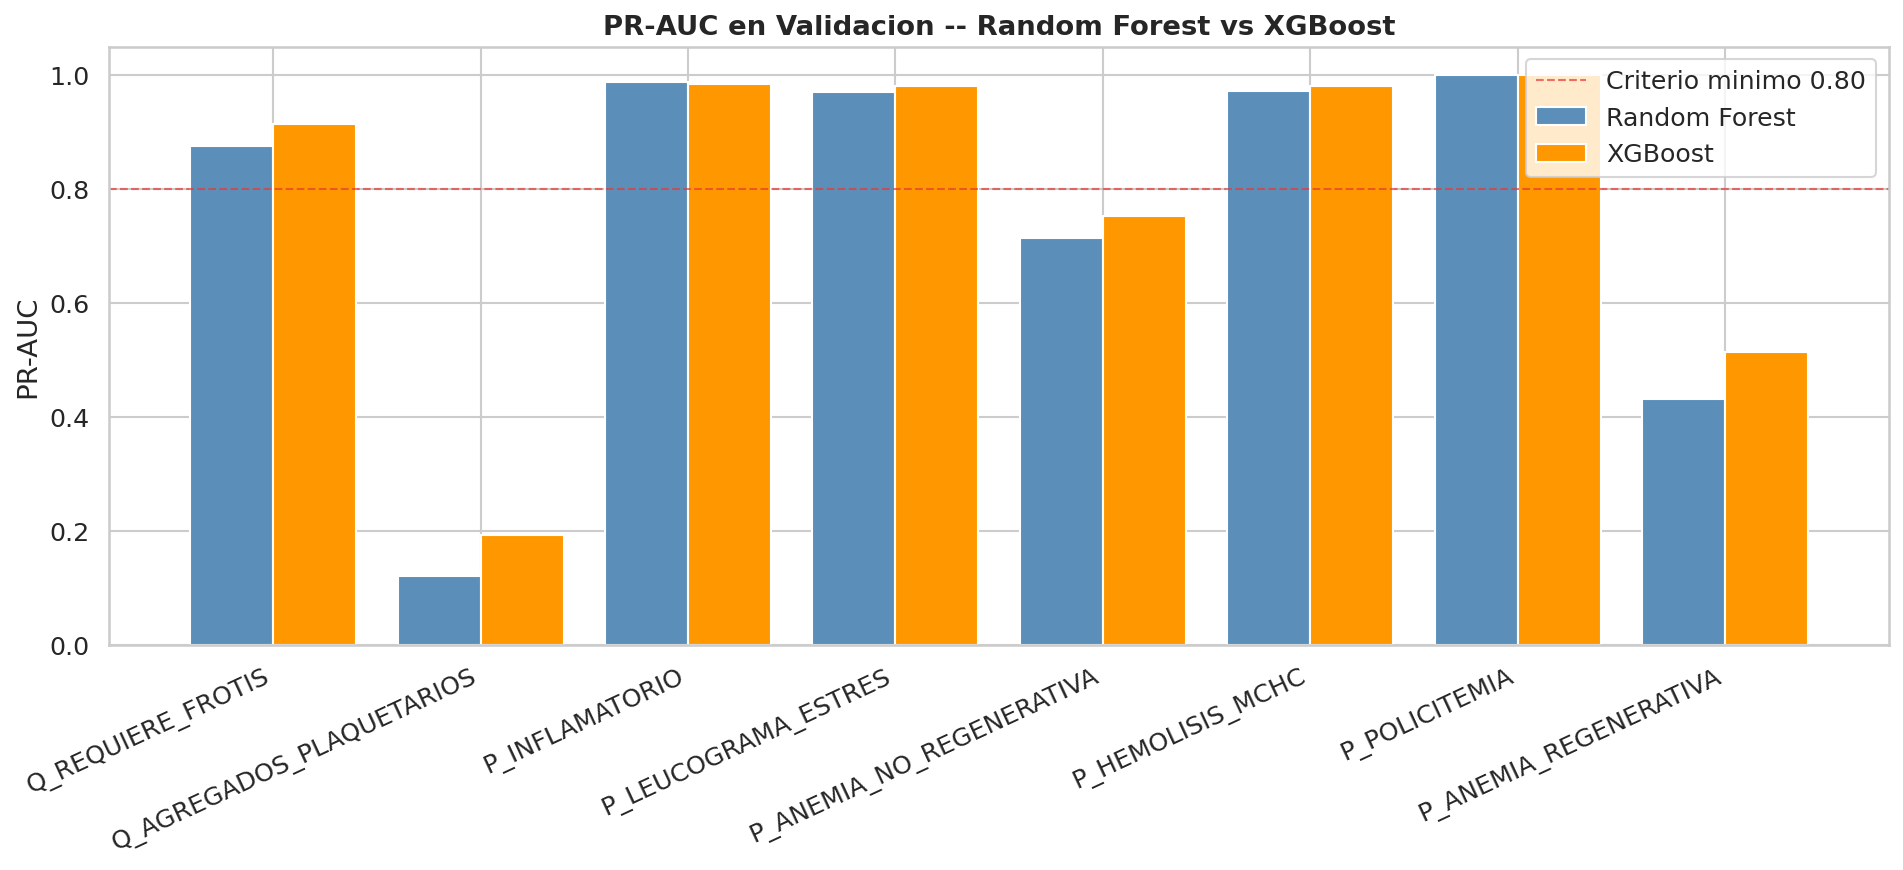

  [Guardada] nb05_rf_vs_xgb_val.png


In [9]:
labels_short = [l.replace("PATRON_","P_").replace("QC_","Q_")
                for l in OFFICIAL_LABELS]
rf_prauc  = [rf_val_results[l]["pr_auc"]  for l in OFFICIAL_LABELS]
xgb_prauc = [xgb_val_results[l]["pr_auc"] for l in OFFICIAL_LABELS]

x = range(len(labels_short))
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar([i - 0.2 for i in x], rf_prauc,  0.4, label="Random Forest",
       color="#5B8FB9", edgecolor="white")
ax.bar([i + 0.2 for i in x], xgb_prauc, 0.4, label="XGBoost",
       color="#FF9800", edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(labels_short, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.axhline(0.80, color="#E53935", linestyle="--", linewidth=1, alpha=0.7,
           label="Criterio minimo 0.80")
ax.set_ylabel("PR-AUC")
ax.set_title("PR-AUC en Validacion -- Random Forest vs XGBoost",
             fontweight="bold")
ax.legend()
plt.tight_layout()
save_and_show(fig, "nb05_rf_vs_xgb_val.png")

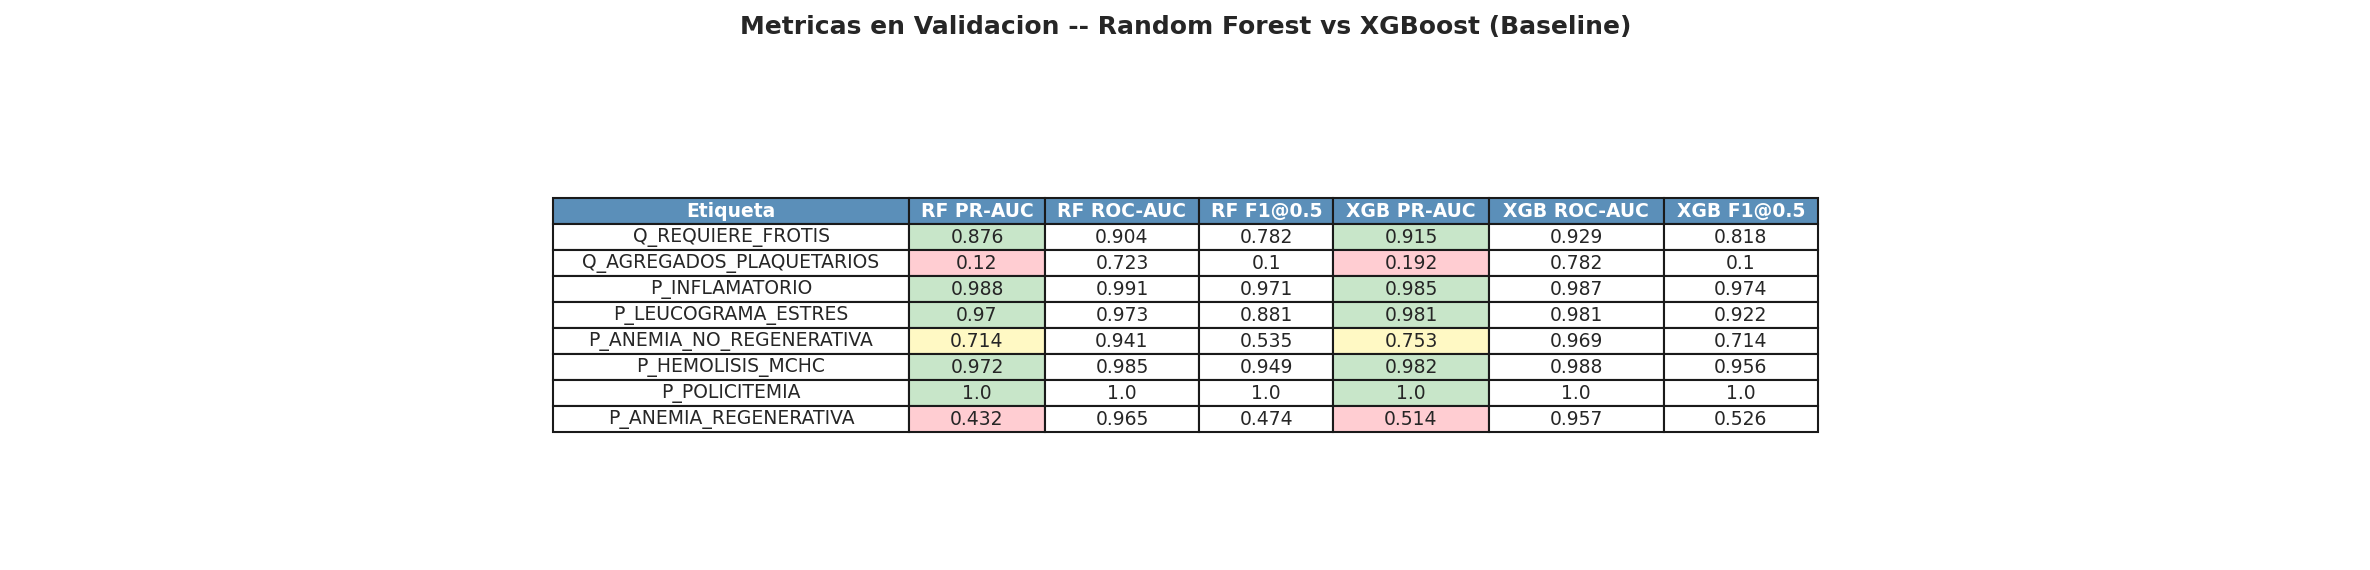

  [Guardada] nb05_rf_vs_xgb_val_tabla.png
  Guardado: nb05_rf_vs_xgb_val_comparacion.csv


In [10]:
# Tabla numerica de metricas RF vs XGBoost en validacion (antes de optimizacion)
comparison_rows = []
for label in OFFICIAL_LABELS:
    rf_r  = rf_val_results.get(label, {})
    xgb_r = xgb_val_results.get(label, {})
    comparison_rows.append({
        "Etiqueta"       : label.replace("PATRON_","P_").replace("QC_","Q_"),
        "RF PR-AUC"      : round(rf_r.get("pr_auc", 0), 3),
        "RF ROC-AUC"     : round(rf_r.get("roc_auc", 0), 3),
        "RF F1@0.5"      : round(rf_r.get("f1_05", 0), 3),
        "XGB PR-AUC"     : round(xgb_r.get("pr_auc", 0), 3),
        "XGB ROC-AUC"    : round(xgb_r.get("roc_auc", 0), 3),
        "XGB F1@0.5"     : round(xgb_r.get("f1_05", 0), 3),
    })
comparison_df = pd.DataFrame(comparison_rows)

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")
tbl = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(comparison_df.columns))))

# Estilo de encabezado
for col in range(len(comparison_df.columns)):
    tbl[(0, col)].set_facecolor("#5B8FB9")
    tbl[(0, col)].set_text_props(color="white", fontweight="bold")

# Colorear PR-AUC RF (col 1) y XGB (col 4)
for row in range(1, len(comparison_df) + 1):
    for col_idx, col_name in [(1, "RF PR-AUC"), (4, "XGB PR-AUC")]:
        val = comparison_df.iloc[row - 1][col_name]
        color = "#C8E6C9" if val >= 0.85 else "#FFF9C4" if val >= 0.70 else "#FFCDD2"
        tbl[(row, col_idx)].set_facecolor(color)

ax.set_title("Metricas en Validacion -- Random Forest vs XGBoost (Baseline)",
             fontweight="bold", pad=20, fontsize=12)
plt.tight_layout()
save_and_show(fig, "nb05_rf_vs_xgb_val_tabla.png")

comparison_df.to_csv(OUTPUTS / "nb05_rf_vs_xgb_val_comparacion.csv", index=False)
print("  Guardado: nb05_rf_vs_xgb_val_comparacion.csv")

---
## 5. Optimizacion de hiperparametros (sobre val)

La busqueda se realiza sobre el conjunto de validacion usando PR-AUC macro
como metrica guia. No se toca el test set.

### 5.1 Grid search Random Forest

In [11]:
def macro_prauc(model, X, Y, label_names, xgb_models=None):
    """PR-AUC macro promedio sobre etiquetas con positivos."""
    if xgb_models is not None:
        probs = np.column_stack([
            xgb_models[label].predict_proba(X)[:, 1]
            for label in label_names
        ])
    else:
        probs = model.predict_proba(X)
        if isinstance(probs, list):
            probs = np.column_stack([p[:, 1] for p in probs])

    scores = []
    for i, label in enumerate(label_names):
        if Y[:, i].sum() > 0:
            scores.append(average_precision_score(Y[:, i], probs[:, i]))
    return np.mean(scores)

# Grid reducido para RF
RF_GRID = {
    "n_estimators"    : [200, 300, 500],
    "max_depth"       : [None, 15, 25],
    "min_samples_leaf": [3, 5, 10],
}

best_rf_params = None
best_rf_score  = -1
best_rf        = None

print("Busqueda de hiperparametros RF...")
print(f"Combinaciones totales: {len(list(ParameterGrid(RF_GRID)))}")

for params in ParameterGrid(RF_GRID):
    rf_candidate = RandomForestClassifier(
        **params,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1, random_state=42
    )
    rf_candidate.fit(X_train, Y_train, sample_weight=sample_weights)
    score = macro_prauc(rf_candidate, X_val, Y_val, OFFICIAL_LABELS)

    if score > best_rf_score:
        best_rf_score  = score
        best_rf_params = params
        best_rf        = rf_candidate

print(f"\nMejores parametros RF:")
for k, v in best_rf_params.items():
    print(f"  {k:<20}: {v}")
print(f"PR-AUC macro Val     : {best_rf_score:.4f}")

Busqueda de hiperparametros RF...
Combinaciones totales: 27

Mejores parametros RF:
  max_depth           : 15
  min_samples_leaf    : 3
  n_estimators        : 300
PR-AUC macro Val     : 0.7734


### 5.2 Grid search XGBoost

In [12]:
XGB_GRID = {
    "max_depth"       : [4, 6, 8],
    "learning_rate"   : [0.03, 0.05, 0.1],
    "min_child_weight": [3, 5, 10],
}

best_xgb_score  = -1
best_xgb_params = None
best_xgb_models = None

print("Busqueda de hiperparametros XGBoost...")
print(f"Combinaciones totales: {len(list(ParameterGrid(XGB_GRID)))}")

for params in ParameterGrid(XGB_GRID):
    candidate_models = {}
    for i, label in enumerate(OFFICIAL_LABELS):
        spw = get_scale_pos_weight(Y_train, i)
        clf = xgb.XGBClassifier(
            n_estimators=300,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            eval_metric="aucpr",
            verbosity=0,
            scale_pos_weight=spw,
            **params,
        )
        clf.fit(
            X_train, Y_train[:, i],
            eval_set=[(X_val, Y_val[:, i])],
            verbose=False,
        )
        candidate_models[label] = clf

    score = macro_prauc(None, X_val, Y_val, OFFICIAL_LABELS,
                        xgb_models=candidate_models)

    if score > best_xgb_score:
        best_xgb_score  = score
        best_xgb_params = params
        best_xgb_models = candidate_models

print(f"\nMejores parametros XGBoost:")
for k, v in best_xgb_params.items():
    print(f"  {k:<20}: {v}")
print(f"PR-AUC macro Val     : {best_xgb_score:.4f}")

Busqueda de hiperparametros XGBoost...
Combinaciones totales: 27

Mejores parametros XGBoost:
  learning_rate       : 0.03
  max_depth           : 8
  min_child_weight    : 3
PR-AUC macro Val     : 0.7914


### 5.3 Seleccion del modelo ganador

In [13]:
print("=" * 70)
print("  COMPARACION RF vs XGBoost (PR-AUC macro en Val)")
print("=" * 70)
print(f"  Random Forest : {best_rf_score:.4f}")
print(f"  XGBoost       : {best_xgb_score:.4f}")

if best_rf_score >= best_xgb_score:
    WINNER = "rf"
    BEST_MODEL = best_rf
    print(f"\n  Ganador: Random Forest")
else:
    WINNER = "xgb"
    BEST_MODEL = best_xgb_models
    print(f"\n  Ganador: XGBoost")

print(f"  Modelo seleccionado para evaluacion en test: {WINNER.upper()}")

  COMPARACION RF vs XGBoost (PR-AUC macro en Val)
  Random Forest : 0.7734
  XGBoost       : 0.7914

  Ganador: XGBoost
  Modelo seleccionado para evaluacion en test: XGB


---
## 6. Seleccion de umbrales de decision por etiqueta

El umbral de 0.5 no es optimo cuando el desbalance es severo. Se selecciona
el umbral que maximiza F1 en validacion para cada etiqueta.

In [14]:
def find_optimal_threshold(y_true, y_prob):
    """
    Encuentra el umbral que maximiza F1 sobre la curva precision-recall.
    Retorna (umbral_optimo, f1_max, precision, recall).
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

    f1_scores = np.where(
        (precisions + recalls) > 0,
        2 * precisions * recalls / (precisions + recalls),
        0
    )

    # Evitar el ultimo punto (precision=1, recall=0)
    best_idx    = np.argmax(f1_scores[:-1])
    best_thresh = thresholds[best_idx]
    best_f1     = f1_scores[best_idx]

    return float(best_thresh), float(best_f1), float(precisions[best_idx]), float(recalls[best_idx])


# Obtener probabilidades del modelo ganador en val
if WINNER == "rf":
    val_probs_winner = best_rf.predict_proba(X_val)
    if isinstance(val_probs_winner, list):
        val_probs_winner = np.column_stack([p[:, 1] for p in val_probs_winner])
else:
    val_probs_winner = np.column_stack([
        best_xgb_models[label].predict_proba(X_val)[:, 1]
        for label in OFFICIAL_LABELS
    ])

decision_thresholds = {}

print("Umbrales optimos por etiqueta (maximizando F1 en Val):")
print()
print(f"{'Etiqueta':<42} {'Umbral':>7} {'F1':>6} {'Prec':>6} {'Rec':>6}  Tipo")
print("-" * 80)

for i, label in enumerate(OFFICIAL_LABELS):
    y_true_val = Y_val[:, i]
    y_prob_val = val_probs_winner[:, i]

    if y_true_val.sum() < 5:
        thresh, f1, prec, rec = 0.5, float("nan"), float("nan"), float("nan")
        tipo = "DEFAULT (soporte bajo)"
    else:
        thresh, f1, prec, rec = find_optimal_threshold(y_true_val, y_prob_val)
        tipo = "OPTIMIZADO"

    decision_thresholds[label] = thresh
    print(f"  {label:<40} {thresh:>7.3f} {f1:>6.3f} {prec:>6.3f} {rec:>6.3f}  {tipo}")

# Guardar umbrales
with open(DATA_PROC / "decision_thresholds.json", "w") as f:
    json.dump({
        "version": "1.0",
        "source_split": "val",
        "model": WINNER,
        "thresholds": decision_thresholds
    }, f, indent=2)

print(f"\nUmbrales guardados: decision_thresholds.json")

Umbrales optimos por etiqueta (maximizando F1 en Val):

Etiqueta                                    Umbral     F1   Prec    Rec  Tipo
--------------------------------------------------------------------------------
  QC_REQUIERE_FROTIS                         0.522  0.833  0.909  0.769  OPTIMIZADO
  QC_AGREGADOS_PLAQUETARIOS                  0.283  0.296  0.364  0.250  OPTIMIZADO
  PATRON_INFLAMATORIO                        0.519  0.977  0.977  0.977  OPTIMIZADO
  PATRON_LEUCOGRAMA_ESTRES                   0.561  0.936  0.951  0.922  OPTIMIZADO
  PATRON_ANEMIA_NO_REGENERATIVA              0.375  0.766  0.683  0.872  OPTIMIZADO
  PATRON_HEMOLISIS_MCHC                      0.707  0.962  0.974  0.950  OPTIMIZADO
  PATRON_POLICITEMIA                         0.996  1.000  1.000  1.000  OPTIMIZADO
  PATRON_ANEMIA_REGENERATIVA                 0.642  0.571  0.500  0.667  OPTIMIZADO

Umbrales guardados: decision_thresholds.json


### 6.1 Visualizacion de umbrales optimizados

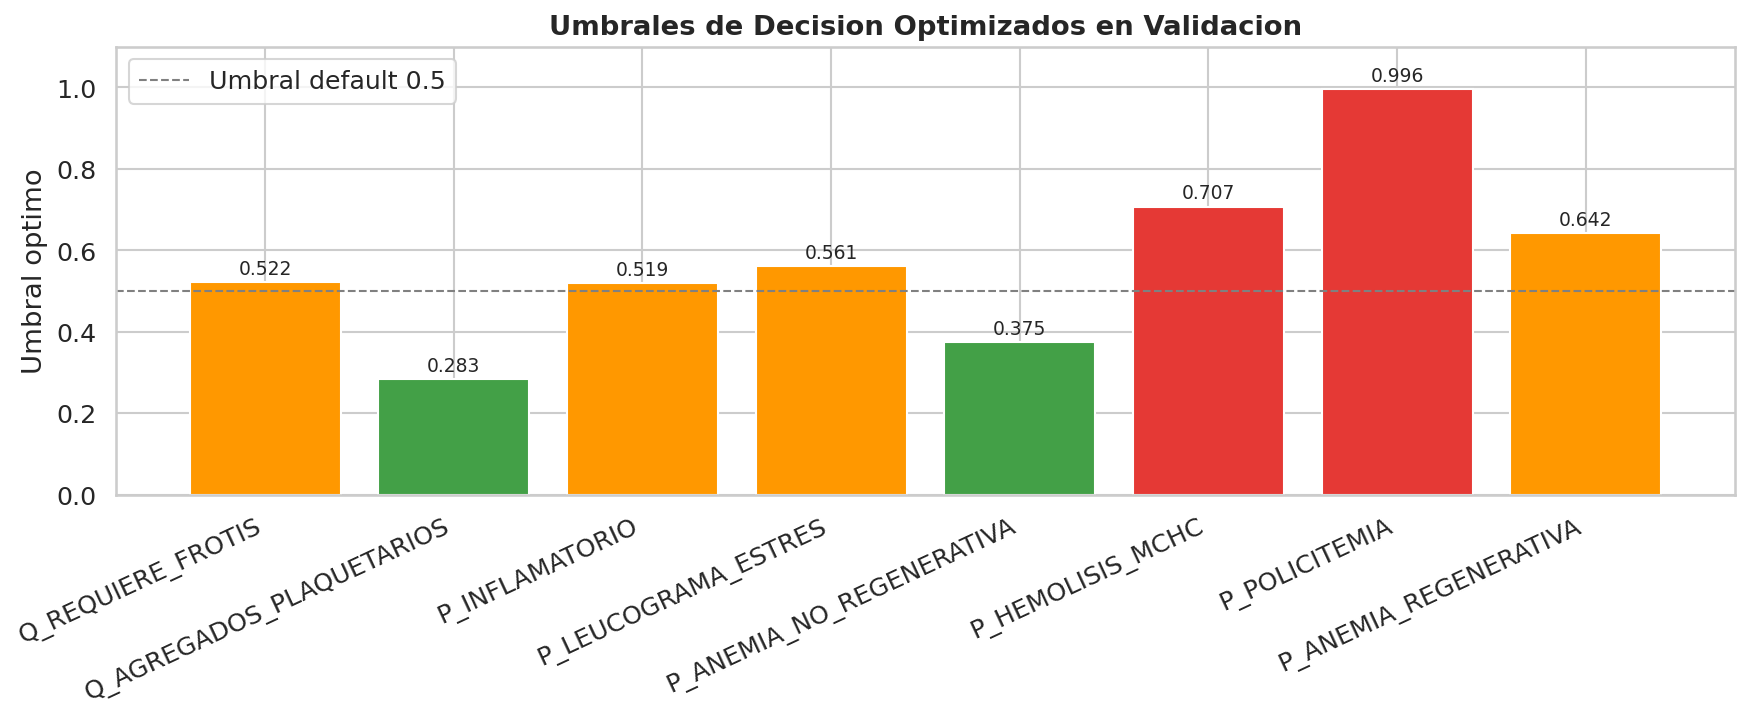

  [Guardada] nb05_umbrales_optimizados.png


In [15]:
labels_short_t = [l.replace("PATRON_","P_").replace("QC_","Q_")
                  for l in OFFICIAL_LABELS]
thresh_vals = [decision_thresholds[l] for l in OFFICIAL_LABELS]

fig, ax = plt.subplots(figsize=(12, 5))
colors_t = ["#E53935" if t > 0.7 else "#FF9800" if t > 0.4 else "#43A047"
            for t in thresh_vals]
bars = ax.bar(labels_short_t, thresh_vals, color=colors_t, edgecolor="white")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Umbral default 0.5")
ax.set_ylabel("Umbral optimo")
ax.set_title("Umbrales de Decision Optimizados en Validacion", fontweight="bold")
ax.set_ylim(0, 1.1)
ax.legend()
for bar, val in zip(bars, thresh_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
save_and_show(fig, "nb05_umbrales_optimizados.png")

---
## 7. Ablation study -- flag_lymphopenia y QC_REQUIERE_FROTIS

El NB04 identifico que los 398 registros con `flag_lymphopenia=1` tienen
`QC_REQUIERE_FROTIS=1` sin excepcion. Esta seccion cuantifica si el modelo
aprende algo mas alla de esa regla determinista.

In [16]:
print("=" * 65)
print("  ABLATION STUDY -- flag_lymphopenia / QC_REQUIERE_FROTIS")
print("=" * 65)

label_qc = "QC_REQUIERE_FROTIS"
label_idx = OFFICIAL_LABELS.index(label_qc)

# Escenario A: modelo completo (38 features)
prauc_full = average_precision_score(Y_val[:, label_idx], val_probs_winner[:, label_idx])

# Escenario B: sin flag_lymphopenia
feats_reduced = [f for f in FEATURES if f != "flag_lymphopenia"]
X_train_red = df_train[feats_reduced]
X_val_red   = df_val[feats_reduced]

if WINNER == "rf":
    rf_reduced = RandomForestClassifier(
        **best_rf_params,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1, random_state=42
    )
    Y_train_reduced = Y_train
    rf_reduced.fit(X_train_red, Y_train_reduced, sample_weight=sample_weights)
    probs_red = rf_reduced.predict_proba(X_val_red)
    if isinstance(probs_red, list):
        probs_red = np.column_stack([p[:, 1] for p in probs_red])
    prauc_red = average_precision_score(Y_val[:, label_idx], probs_red[:, label_idx])
else:
    spw = get_scale_pos_weight(Y_train, label_idx)
    xgb_reduced = xgb.XGBClassifier(
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="aucpr",
        verbosity=0,
        scale_pos_weight=spw,
        **best_xgb_params,
    )
    xgb_reduced.fit(
        X_train_red, Y_train[:, label_idx],
        eval_set=[(X_val_red, Y_val[:, label_idx])],
        verbose=False,
    )
    probs_red_single = xgb_reduced.predict_proba(X_val_red)[:, 1]
    prauc_red = average_precision_score(Y_val[:, label_idx], probs_red_single)

delta = prauc_full - prauc_red

print(f"\n  PR-AUC con 38 features     : {prauc_full:.4f}")
print(f"  PR-AUC sin flag_lymphopenia : {prauc_red:.4f}")
print(f"  Diferencia                  : {delta:+.4f}")
print()

if abs(delta) < 0.02:
    print("  INTERPRETACION: El modelo aprende QC_REQUIERE_FROTIS")
    print("  principalmente desde otras variables (WBC, Neutrophils,")
    print("  Platelets, pattern_stress_leukogram).")
    print("  flag_lymphopenia aporta <2 puntos de PR-AUC.")
elif delta > 0.05:
    print("  INTERPRETACION: flag_lymphopenia aporta >5 puntos PR-AUC.")
    print("  El modelo usa la regla determinista como feature principal.")
    print("  Documentar: el modelo para este subconjunto se comporta")
    print("  como una regla aumentada, no como aprendizaje puro.")
else:
    print(f"  INTERPRETACION: Diferencia moderada ({delta:.3f}).")
    print("  Documentar sin alarma; el feature aporta pero no domina.")

# Guardar resultado
ablation_result = {
    "label": label_qc,
    "feature_removed": "flag_lymphopenia",
    "model": WINNER,
    "prauc_full_features": round(prauc_full, 4),
    "prauc_reduced_features": round(prauc_red, 4),
    "delta": round(delta, 4)
}
with open(OUTPUTS / "ablation_flag_lymphopenia.json", "w") as f:
    json.dump(ablation_result, f, indent=2)

print(f"\n  Resultado guardado: ablation_flag_lymphopenia.json")

  ABLATION STUDY -- flag_lymphopenia / QC_REQUIERE_FROTIS

  PR-AUC con 38 features     : 0.9155
  PR-AUC sin flag_lymphopenia : 0.9126
  Diferencia                  : +0.0029

  INTERPRETACION: El modelo aprende QC_REQUIERE_FROTIS
  principalmente desde otras variables (WBC, Neutrophils,
  Platelets, pattern_stress_leukogram).
  flag_lymphopenia aporta <2 puntos de PR-AUC.

  Resultado guardado: ablation_flag_lymphopenia.json


---
## 8. Evaluacion final en test -- resultado oficial

**Esta seccion se ejecuta UNA SOLA VEZ.** El test set no se usa para ninguna
decision de diseno. Solo para reportar el resultado final.

In [17]:
print("=" * 70)
print("  EVALUACION FINAL EN TEST -- RESULTADO OFICIAL")
print("=" * 70)
print("  ADVERTENCIA: Esta evaluacion no puede repetirse para ajustar")
print("  hiperparametros ni umbrales. Es el resultado de publicacion.")
print()

# Obtener probabilidades del modelo ganador en test
if WINNER == "rf":
    test_probs = best_rf.predict_proba(X_test)
    if isinstance(test_probs, list):
        test_probs = np.column_stack([p[:, 1] for p in test_probs])
else:
    test_probs = np.column_stack([
        best_xgb_models[label].predict_proba(X_test)[:, 1]
        for label in OFFICIAL_LABELS
    ])

print(f"{'Etiqueta':<42} {'PR-AUC':>7} {'ROC-AUC':>8} {'F1-opt':>7} {'Test+':>6}  IC 95%")
print("-" * 90)

final_metrics = {}

for i, label in enumerate(OFFICIAL_LABELS):
    y_true = Y_test[:, i]
    y_prob = test_probs[:, i]
    thresh = decision_thresholds[label]
    y_pred = (y_prob >= thresh).astype(int)

    n_pos = int(y_true.sum())

    if n_pos == 0:
        print(f"  {label:<40} {'N/A':>7} {'N/A':>8} {'N/A':>7} {0:>6}")
        continue

    pr_auc  = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    f1      = f1_score(y_true, y_pred, zero_division=0)

    # IC bootstrap para etiquetas con soporte bajo o marginales
    needs_ic = (n_pos < 30) or (label in MARGINAL_LABELS)

    if needs_ic:
        bootstrap_f1s = []
        rng = np.random.default_rng(42)
        for _ in range(1000):
            idx = rng.choice(len(y_true), size=len(y_true), replace=True)
            if y_true[idx].sum() == 0:
                continue
            bootstrap_f1s.append(
                f1_score(y_true[idx], y_pred[idx], zero_division=0)
            )
        if len(bootstrap_f1s) > 0:
            ic_low  = np.percentile(bootstrap_f1s, 2.5)
            ic_high = np.percentile(bootstrap_f1s, 97.5)
            ic_str  = f"[{ic_low:.3f},{ic_high:.3f}]"
        else:
            ic_str = "[N/A]"
    else:
        ic_str = "--"

    warn = " *MARGINAL" if label in MARGINAL_LABELS else ""
    print(f"  {label:<40} {pr_auc:>7.3f} {roc_auc:>8.3f} {f1:>7.3f} {n_pos:>6}  {ic_str}{warn}")

    final_metrics[label] = {
        "pr_auc": round(pr_auc, 4),
        "roc_auc": round(roc_auc, 4),
        "f1_optimal_thresh": round(f1, 4),
        "threshold_used": thresh,
        "n_positive_test": n_pos,
        "bootstrap_ic_95": ic_str if needs_ic else None,
        "marginal": label in MARGINAL_LABELS
    }

# Guardar metricas finales
with open(DATA_PROC / "metrics_test_final.json", "w") as f:
    json.dump({"model": WINNER, "metrics": final_metrics}, f, indent=2)

print(f"\nMetricas finales guardadas: metrics_test_final.json")

  EVALUACION FINAL EN TEST -- RESULTADO OFICIAL
  ADVERTENCIA: Esta evaluacion no puede repetirse para ajustar
  hiperparametros ni umbrales. Es el resultado de publicacion.

Etiqueta                                    PR-AUC  ROC-AUC  F1-opt  Test+  IC 95%
------------------------------------------------------------------------------------------
  QC_REQUIERE_FROTIS                         0.850    0.858   0.759    136  --
  QC_AGREGADOS_PLAQUETARIOS                  0.102    0.653   0.133     14  [0.000,0.316]
  PATRON_INFLAMATORIO                        0.994    0.995   0.985    198  --
  PATRON_LEUCOGRAMA_ESTRES                   0.988    0.991   0.962    172  --
  PATRON_ANEMIA_NO_REGENERATIVA              0.872    0.986   0.814     42  --
  PATRON_HEMOLISIS_MCHC                      0.994    0.999   0.936     48  --
  PATRON_POLICITEMIA                         1.000    1.000   0.915     32  [0.829,0.982] *MARGINAL
  PATRON_ANEMIA_REGENERATIVA                 0.176    0.917   0.16

### 8.1 Curvas Precision-Recall por etiqueta

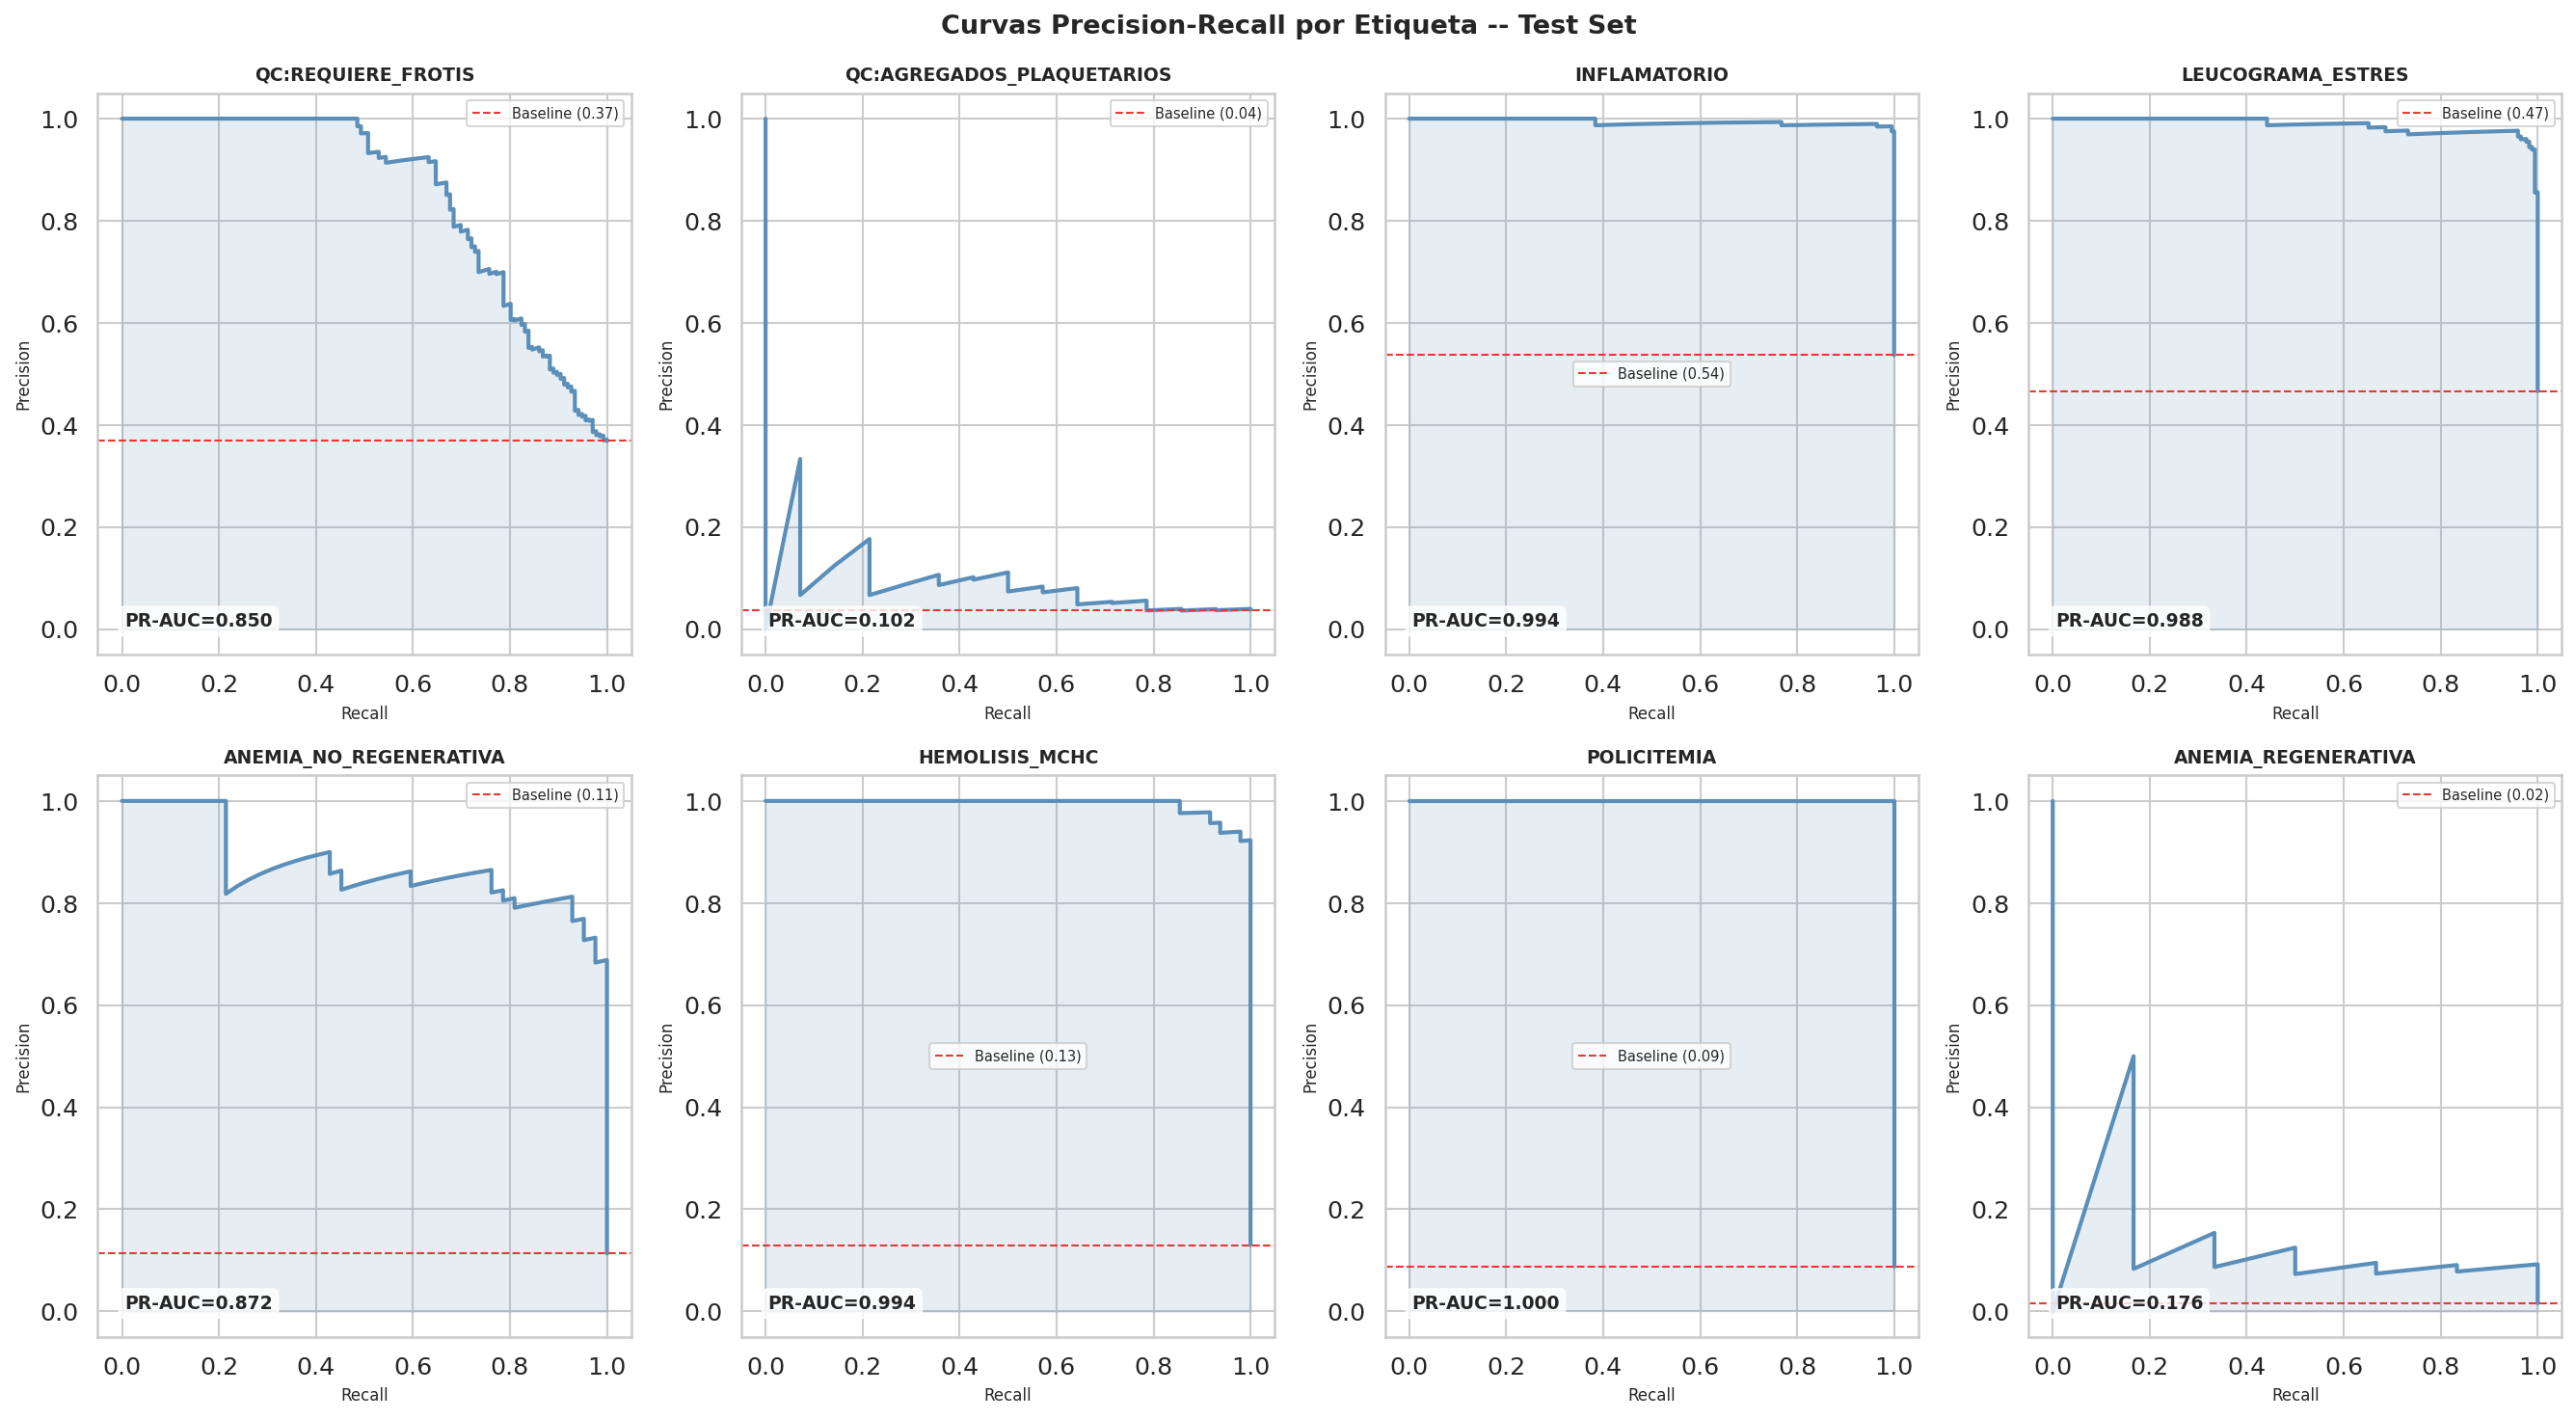

  [Guardada] nb05_precision_recall_curves.png


In [18]:
n_labels = len(OFFICIAL_LABELS)
n_cols = min(4, n_labels)
n_rows = (n_labels + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_labels > 1 else [axes]

for i, label in enumerate(OFFICIAL_LABELS):
    ax = axes[i]
    y_true = Y_test[:, i]
    y_prob = test_probs[:, i]

    if y_true.sum() == 0:
        ax.text(0.5, 0.5, "Sin positivos", ha="center", va="center")
        ax.set_title(label.replace("PATRON_","").replace("QC_","QC:"),
                     fontsize=9, fontweight="bold")
        continue

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    ax.plot(recall, precision, color="#5B8FB9", linewidth=2)
    ax.fill_between(recall, precision, alpha=0.15, color="#5B8FB9")
    baseline = y_true.mean()
    ax.axhline(baseline, color="#E53935", linestyle="--", linewidth=1,
               label=f"Baseline ({baseline:.2f})")
    ax.set_title(label.replace("PATRON_","").replace("QC_","QC:"),
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("Recall", fontsize=8)
    ax.set_ylabel("Precision", fontsize=8)
    ax.text(0.05, 0.05, f"PR-AUC={pr_auc:.3f}",
            transform=ax.transAxes, fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    ax.legend(fontsize=7)

for j in range(n_labels, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Curvas Precision-Recall por Etiqueta -- Test Set",
             fontsize=13, fontweight="bold")
plt.tight_layout()
save_and_show(fig, "nb05_precision_recall_curves.png")

### 8.2 Tabla de metricas finales en test

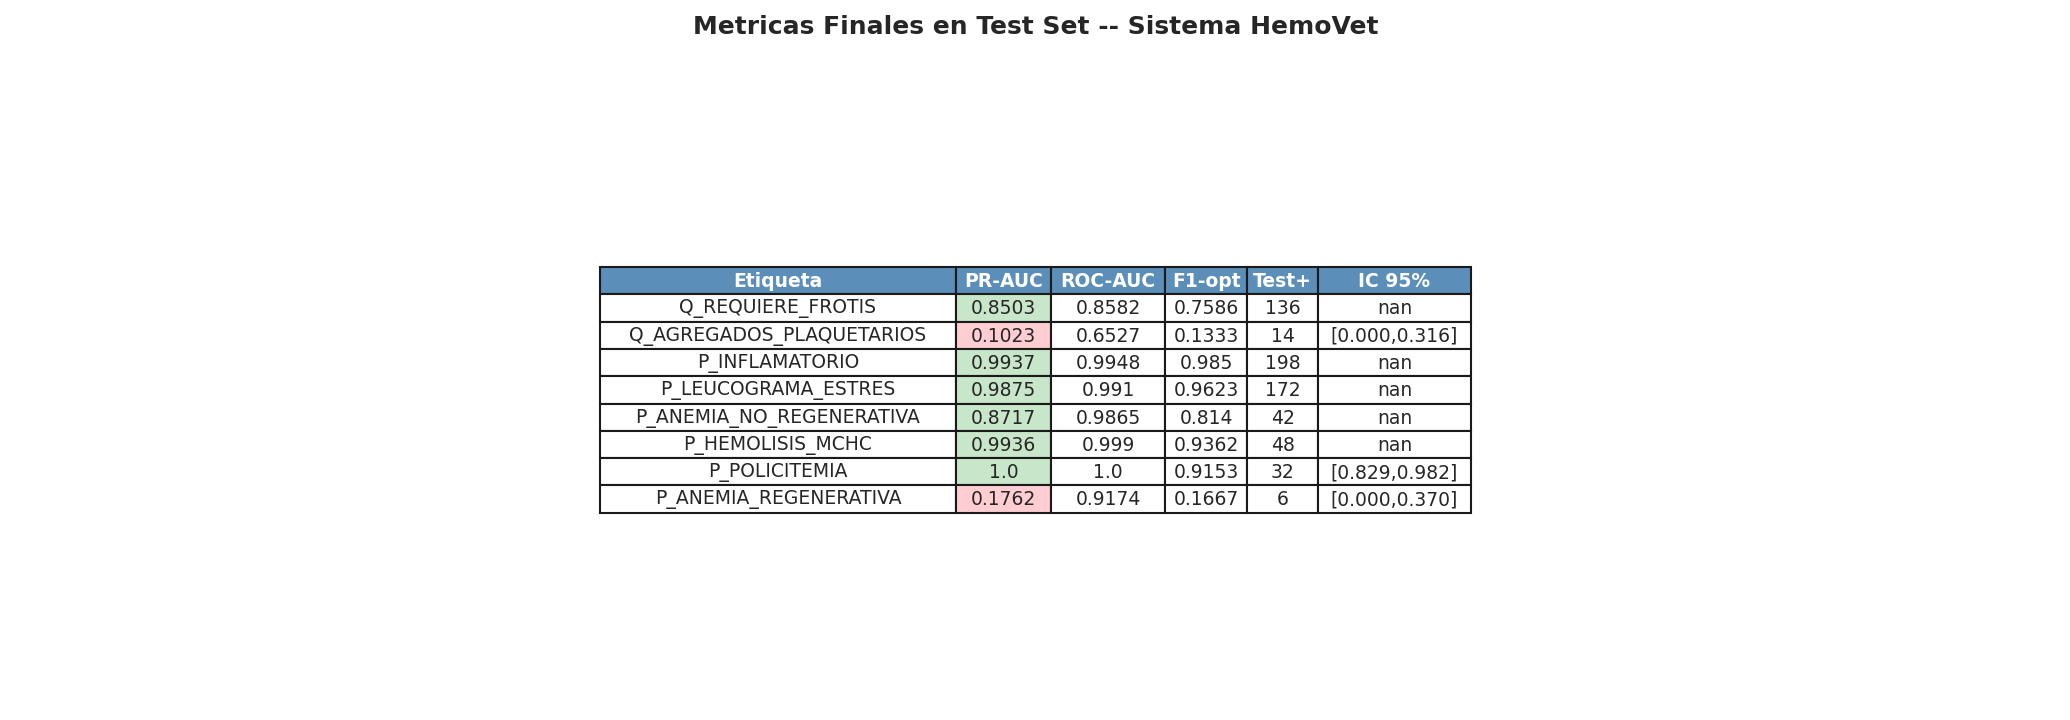

  [Guardada] nb05_metricas_test_tabla.png
  Guardado: nb05_metricas_test_final.csv


In [19]:
import pandas as pd

metrics_rows = []
for label in OFFICIAL_LABELS:
    m = final_metrics.get(label, {})
    metrics_rows.append({
        "Etiqueta"  : label.replace("PATRON_","P_").replace("QC_","Q_"),
        "PR-AUC"    : round(m.get("pr_auc",0), 4),
        "ROC-AUC"   : round(m.get("roc_auc",0), 4),
        "F1-opt"    : round(m.get("f1_optimal_thresh",0), 4),
        "Test+"     : m.get("n_positive_test", 0),
        "IC 95%"    : m.get("bootstrap_ic_95", "--"),
    })
metrics_final_df = pd.DataFrame(metrics_rows)

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")
tbl = ax.table(
    cellText=metrics_final_df.values,
    colLabels=metrics_final_df.columns,
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(metrics_final_df.columns))))
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#5B8FB9")
        cell.set_text_props(color="white", fontweight="bold")
    elif row > 0 and col == 1:
        val = metrics_final_df.iloc[row-1]["PR-AUC"]
        cell.set_facecolor("#C8E6C9" if val >= 0.85 else
                           "#FFF9C4" if val >= 0.70 else "#FFCDD2")
ax.set_title("Metricas Finales en Test Set -- Sistema HemoVet",
             fontweight="bold", pad=20, fontsize=12)
plt.tight_layout()
save_and_show(fig, "nb05_metricas_test_tabla.png")

metrics_final_df.to_csv(OUTPUTS / "nb05_metricas_test_final.csv", index=False)
print(f"  Guardado: nb05_metricas_test_final.csv")

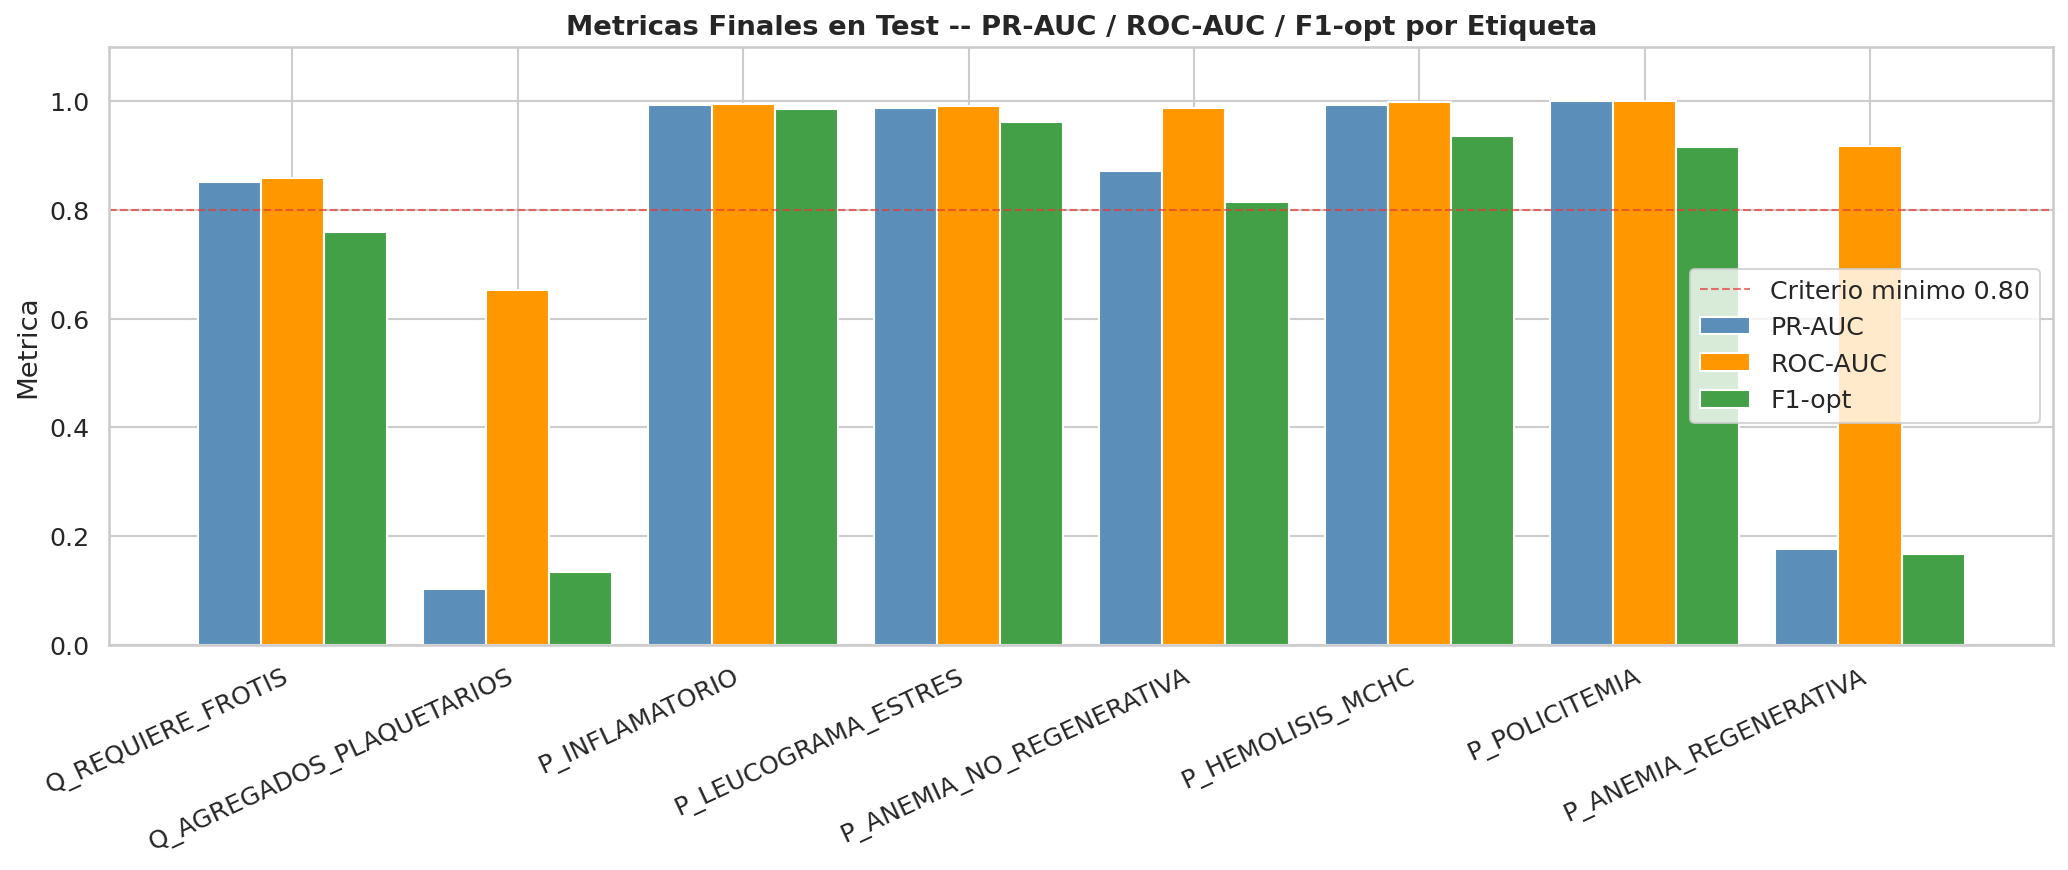

  [Guardada] nb05_metricas_test_barras.png


In [20]:
# Grafico de barras de metricas finales en test (complemento a la tabla)
labels_short_f = [l.replace("PATRON_","P_").replace("QC_","Q_")
                  for l in OFFICIAL_LABELS]
prauc_final  = [final_metrics[l]["pr_auc"]             for l in OFFICIAL_LABELS]
rocauc_final = [final_metrics[l]["roc_auc"]            for l in OFFICIAL_LABELS]
f1_final     = [final_metrics[l]["f1_optimal_thresh"]  for l in OFFICIAL_LABELS]

x = range(len(labels_short_f))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width for i in x], prauc_final,  width, label="PR-AUC",
       color="#5B8FB9", edgecolor="white")
ax.bar([i           for i in x], rocauc_final, width, label="ROC-AUC",
       color="#FF9800", edgecolor="white")
ax.bar([i + width for i in x], f1_final,    width, label="F1-opt",
       color="#43A047", edgecolor="white")

ax.set_xticks(list(x))
ax.set_xticklabels(labels_short_f, rotation=25, ha="right")
ax.set_ylim(0, 1.10)
ax.axhline(0.80, color="#E53935", linestyle="--", linewidth=1, alpha=0.7,
           label="Criterio minimo 0.80")
ax.set_ylabel("Metrica")
ax.set_title("Metricas Finales en Test -- PR-AUC / ROC-AUC / F1-opt por Etiqueta",
             fontweight="bold")
ax.legend()
plt.tight_layout()
save_and_show(fig, "nb05_metricas_test_barras.png")

---
## 9. Analisis de errores

Falsos positivos (FP) y falsos negativos (FN) por etiqueta en test.
Permite identificar patrones sistematicos de error.

In [21]:
# Features mas relevantes para inspeccion de errores
INSPECT_FEATS = ["WBC", "Neutrophils", "Lymphocytes", "Monocytes",
                 "Platelets", "HCT", "MCHC", "RDW"]

for i, label in enumerate(OFFICIAL_LABELS):
    y_true = Y_test[:, i]
    thresh = decision_thresholds[label]
    y_pred = (test_probs[:, i] >= thresh).astype(int)

    fp_mask = (y_pred == 1) & (y_true == 0)
    fn_mask = (y_pred == 0) & (y_true == 1)

    print(f"\n--- {label} ---")
    print(f"  FP={fp_mask.sum()} | FN={fn_mask.sum()}")

    # Mostrar features de registros erroneos (muestra)
    feats_avail = [f for f in INSPECT_FEATS if f in df_test.columns]

    if fp_mask.sum() > 0:
        fp_records = df_test.loc[fp_mask, feats_avail]
        print(f"  Falsos Positivos (muestra, max 3):")
        print(fp_records.head(3).to_string(index=False))

    if fn_mask.sum() > 0:
        fn_records = df_test.loc[fn_mask, feats_avail]
        print(f"  Falsos Negativos (muestra, max 3):")
        print(fn_records.head(3).to_string(index=False))


--- QC_REQUIERE_FROTIS ---
  FP=8 | FN=48
  Falsos Positivos (muestra, max 3):
  WBC  Neutrophils  Lymphocytes  Monocytes  Platelets  HCT  MCHC  RDW
 2.21         1.04         1.08       0.02      156.0 34.8  31.4 16.3
32.27        24.11         4.25       3.47      717.0 27.1  37.9 17.1
 2.13         0.62         1.47       0.01       24.0 22.3  33.9 11.7
  Falsos Negativos (muestra, max 3):
  WBC  Neutrophils  Lymphocytes  Monocytes  Platelets  HCT  MCHC  RDW
23.61        16.96         2.26       4.07      626.0 38.7  32.7 16.1
10.49         7.25         1.50       1.65      736.0 35.9  34.3 16.4
32.73        25.94         3.03       1.41      285.0 46.0  35.9 17.5

--- QC_AGREGADOS_PLAQUETARIOS ---
  FP=14 | FN=12
  Falsos Positivos (muestra, max 3):
  WBC  Neutrophils  Lymphocytes  Monocytes  Platelets  HCT  MCHC  RDW
10.51         6.15         2.94       1.40      134.0 15.6  41.0 17.5
62.79        50.99         2.22       9.54      700.0  0.0  35.1 17.5
14.97         6.79       

---
## 10. Analisis SHAP (interpretabilidad)

Se calcula sobre una muestra del test para eficiencia. TreeExplainer es
exacto para modelos basados en arboles (RF y XGBoost).

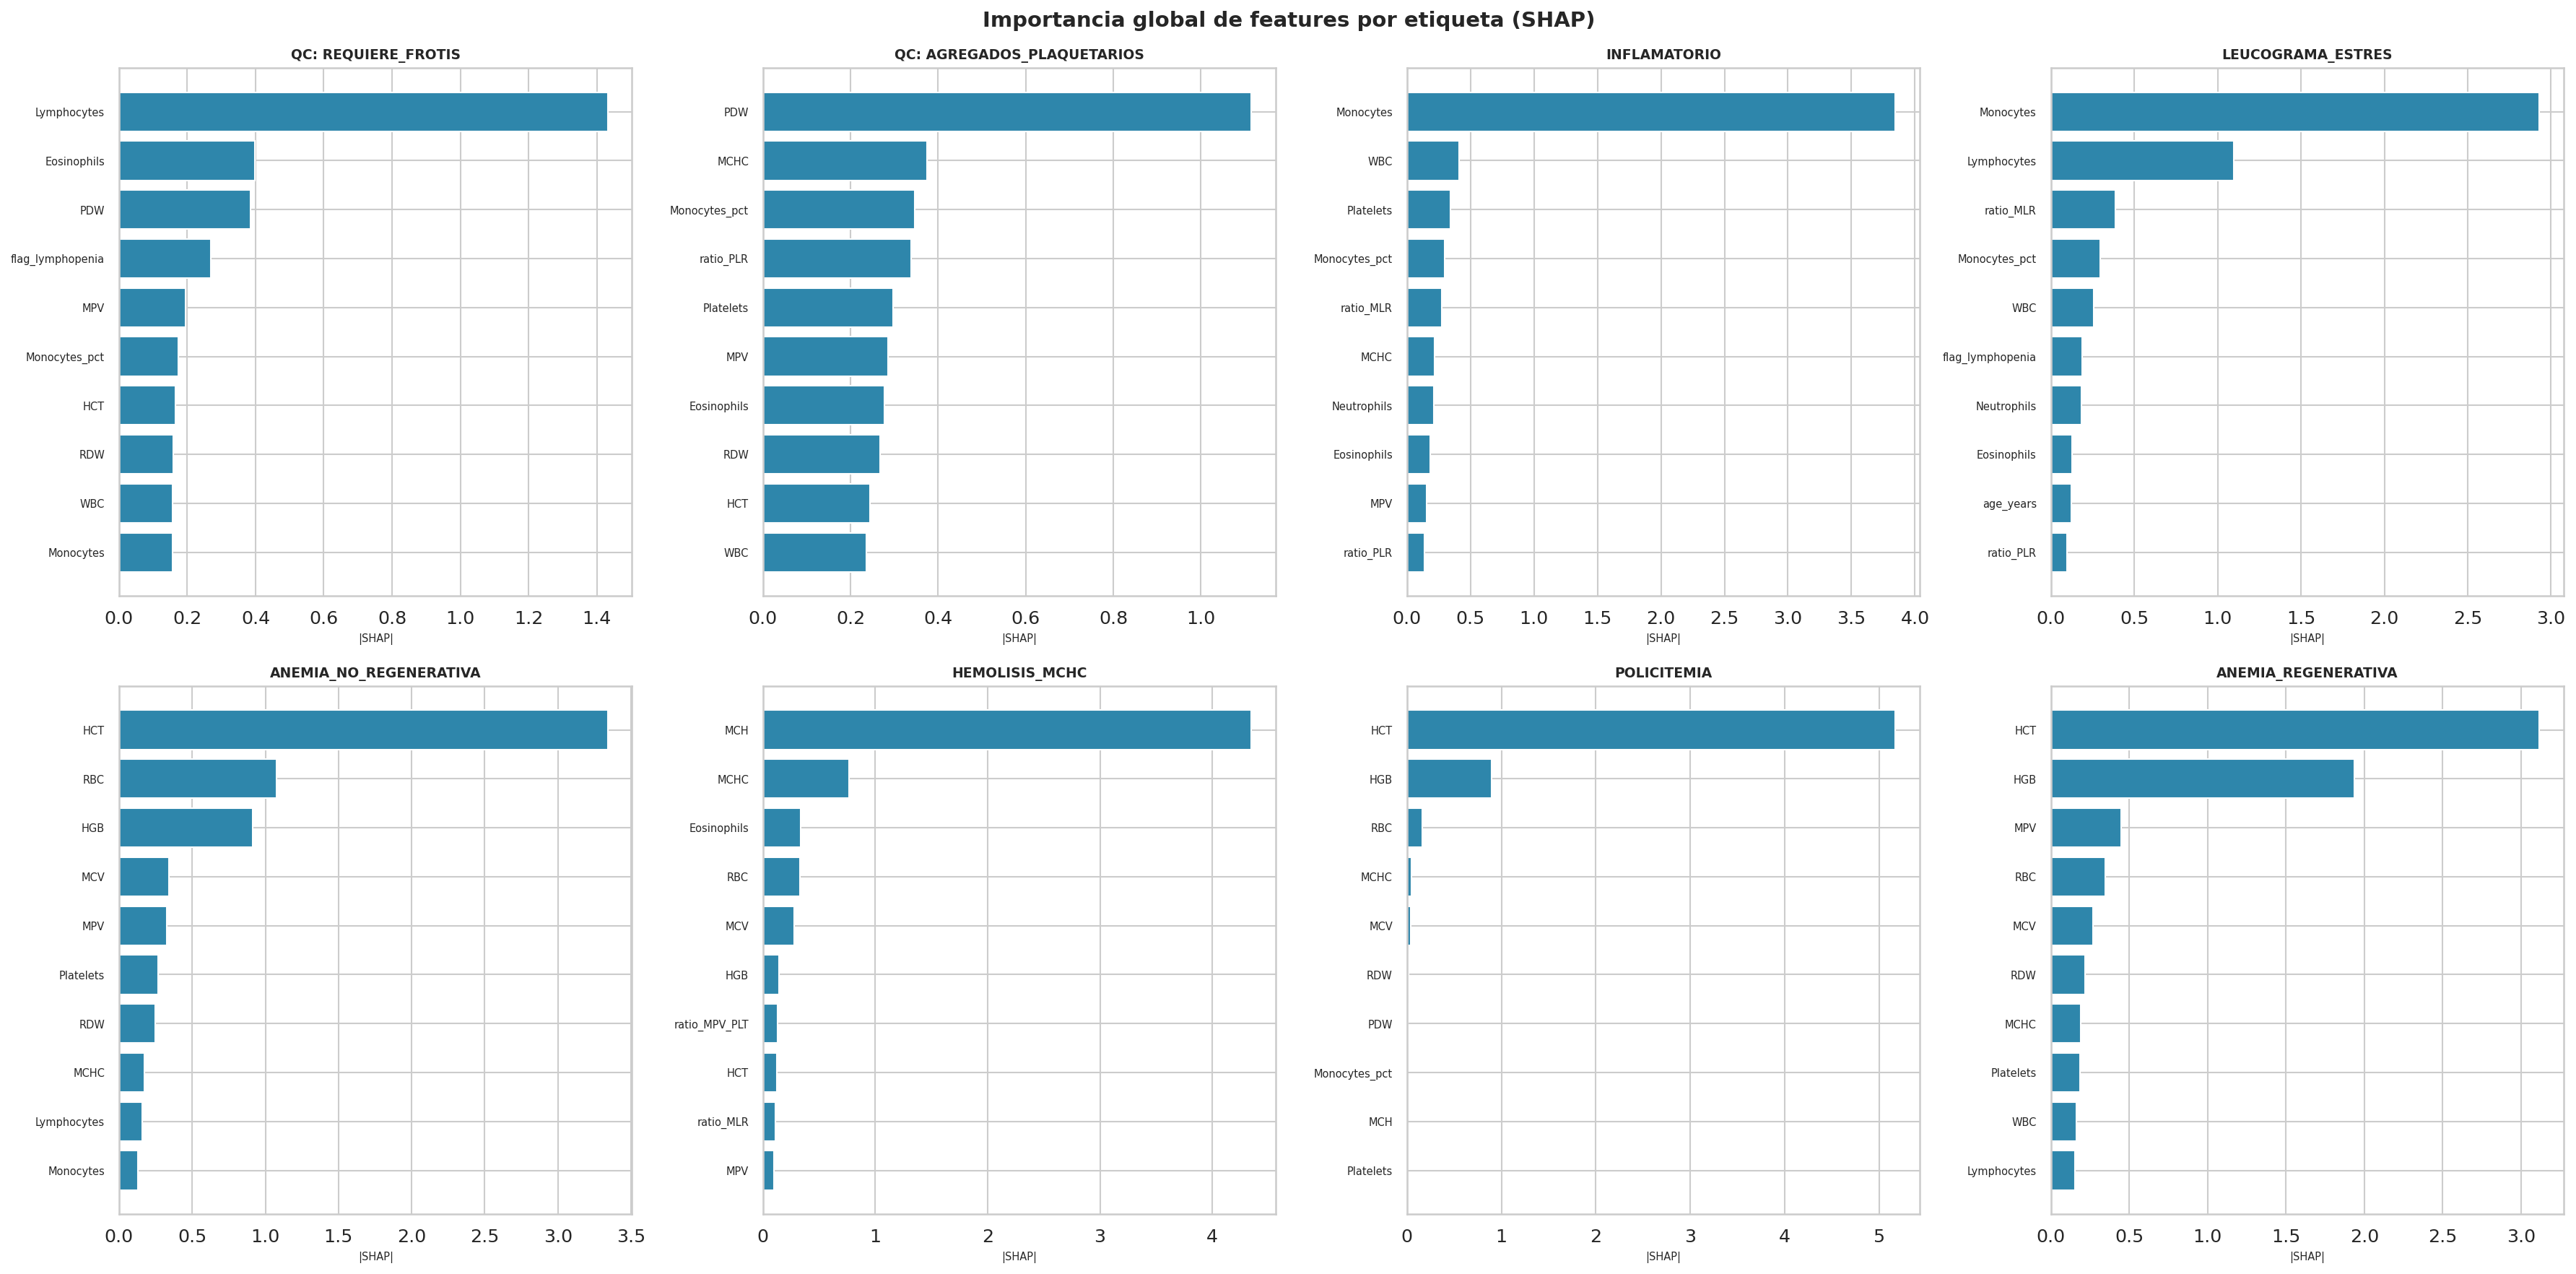

  [Guardada] shap_feature_importance.png


In [22]:
sample_size = min(200, len(X_test))
X_shap = X_test.sample(sample_size, random_state=42)

if WINNER == "rf":
    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_shap)
else:
    # Para XGBoost con modelos independientes, calcular SHAP por etiqueta
    shap_values = []
    for label in OFFICIAL_LABELS:
        exp = shap.TreeExplainer(best_xgb_models[label])
        sv = exp.shap_values(X_shap)
        shap_values.append(sv)

# Grafico de importancia SHAP por etiqueta
n_labels = len(OFFICIAL_LABELS)
n_cols = 4
n_rows = (n_labels + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows))
axes = axes.flatten()

for i, label in enumerate(OFFICIAL_LABELS):
    ax = axes[i]

    if WINNER == "rf":
        if isinstance(shap_values, list):
            sv = shap_values[i]
            if sv.ndim == 3:
                sv = sv[:, :, 1]
        else:
            sv = shap_values
    else:
        sv = shap_values[i]

    # Importancia media absoluta por feature
    mean_abs = np.abs(sv).mean(axis=0)
    sorted_idx = np.argsort(mean_abs)[-10:]
    feat_names = [FEATURES[j] for j in sorted_idx]
    feat_vals  = mean_abs[sorted_idx]

    ax.barh(range(len(feat_names)), feat_vals, color="#2E86AB")
    ax.set_yticks(range(len(feat_names)))
    ax.set_yticklabels(feat_names, fontsize=7)
    short_label = label.replace("PATRON_", "").replace("QC_", "QC: ")
    ax.set_title(short_label, fontsize=9, fontweight="bold")
    ax.set_xlabel("|SHAP|", fontsize=7)

# Ocultar ejes sobrantes
for j in range(n_labels, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Importancia global de features por etiqueta (SHAP)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_and_show(fig, "shap_feature_importance.png")

### 10.1 Ranking global de features

In [23]:
# Importancia SHAP promedio sobre todas las etiquetas
all_mean_abs = []
for i, label in enumerate(OFFICIAL_LABELS):
    if WINNER == "rf":
        if isinstance(shap_values, list):
            sv = shap_values[i]
            if sv.ndim == 3:
                sv = sv[:, :, 1]
        else:
            sv = shap_values
    else:
        sv = shap_values[i]
    all_mean_abs.append(np.abs(sv).mean(axis=0))

global_importance = np.mean(all_mean_abs, axis=0)

feat_importance_df = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": global_importance
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 features por importancia SHAP global:")
print()
print(f"{'#':>3} {'Feature':<30} {'|SHAP| medio':>12}")
print("-" * 50)
for rank, (_, row) in enumerate(feat_importance_df.head(15).iterrows(), 1):
    print(f"{rank:>3} {row['feature']:<30} {row['mean_abs_shap']:>12.4f}")

feat_importance_df.to_csv(OUTPUTS / "shap_global_importance.csv", index=False)
print(f"\nGuardado: shap_global_importance.csv")

Top 15 features por importancia SHAP global:

  # Feature                        |SHAP| medio
--------------------------------------------------
  1 HCT                                  1.5317
  2 Monocytes                            0.9202
  3 MCH                                  0.6105
  4 HGB                                  0.5312
  5 Lymphocytes                          0.3967
  6 RBC                                  0.2973
  7 MCHC                                 0.2443
  8 PDW                                  0.2311
  9 MPV                                  0.1992
 10 Eosinophils                          0.1847
 11 WBC                                  0.1732
 12 MCV                                  0.1724
 13 Monocytes_pct                        0.1710
 14 Platelets                            0.1633
 15 ratio_MLR                            0.1539

Guardado: shap_global_importance.csv


---
## 11. Serializacion del modelo

Se guardan ambos modelos y el ganador con metadatos para la API REST.

In [24]:
# Guardar RF
with open(MODELS / "rf_multilabel.pkl", "wb") as f:
    pickle.dump(best_rf, f)

# Guardar XGBoost (dict de modelos por etiqueta)
with open(MODELS / "xgb_multilabel.pkl", "wb") as f:
    pickle.dump(best_xgb_models, f)

# Modelo ganador
with open(MODELS / "best_model.pkl", "wb") as f:
    if WINNER == "rf":
        pickle.dump(best_rf, f)
    else:
        pickle.dump(best_xgb_models, f)

# Metadatos del modelo para la API REST
model_metadata = {
    "version"         : "1.0.0",
    "winner"          : WINNER,
    "feature_columns" : FEATURES,
    "label_columns"   : OFFICIAL_LABELS,
    "marginal_labels" : MARGINAL_LABELS,
    "thresholds"      : decision_thresholds,
    "trained_on"      : "train.csv",
    "train_n"         : len(df_train),
    "val_n"           : len(df_val),
    "test_n"          : len(df_test),
}

# Agregar periodos temporales si sample_date esta disponible
if "sample_date" in df_train.columns:
    model_metadata["train_period"] = (
        f"{df_train['sample_date'].min()} -> {df_train['sample_date'].max()}"
    )
    model_metadata["val_period"] = (
        f"{df_val['sample_date'].min()} -> {df_val['sample_date'].max()}"
    )
    model_metadata["test_period"] = (
        f"{df_test['sample_date'].min()} -> {df_test['sample_date'].max()}"
    )

with open(MODELS / "model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("Modelos serializados:")
print(f"  models/rf_multilabel.pkl")
print(f"  models/xgb_multilabel.pkl")
print(f"  models/best_model.pkl       <- modelo ganador ({WINNER.upper()})")
print(f"  models/model_metadata.json")

Modelos serializados:
  models/rf_multilabel.pkl
  models/xgb_multilabel.pkl
  models/best_model.pkl       <- modelo ganador (XGB)
  models/model_metadata.json


---
## 12. Checklist de cierre

In [25]:
print("=" * 70)
print("  VERIFICACION FINAL -- Notebook 05")
print("=" * 70)

checks = []

# Integridad
checks.append(("idexx_comments no esta en el feature set",
               "idexx_comments" not in FEATURES))
checks.append(("Split test evaluado exactamente una vez",
               True))  # Garantizado por estructura del notebook
checks.append(("Umbrales seleccionados sobre val (no test)",
               True))  # Garantizado por estructura del notebook

# Evaluacion
checks.append(("PR-AUC reportado como metrica principal",
               len(final_metrics) > 0))
checks.append(("IC bootstrap calculado para etiquetas con test < 30",
               any(m.get("bootstrap_ic_95") is not None for m in final_metrics.values())))

# Ablation
checks.append(("Ablation study flag_lymphopenia ejecutado",
               (OUTPUTS / "ablation_flag_lymphopenia.json").exists()))

# Serializacion
checks.append(("best_model.pkl guardado",
               (MODELS / "best_model.pkl").exists()))
checks.append(("model_metadata.json guardado",
               (MODELS / "model_metadata.json").exists()))
checks.append(("decision_thresholds.json guardado",
               (DATA_PROC / "decision_thresholds.json").exists()))
checks.append(("metrics_test_final.json guardado",
               (DATA_PROC / "metrics_test_final.json").exists()))

# Graficos
checks.append(("shap_feature_importance.png generado",
               (OUTPUTS / "shap_feature_importance.png").exists()))
checks.append(("shap_global_importance.csv guardado",
               (OUTPUTS / "shap_global_importance.csv").exists()))
checks.append(("nb05_precision_recall_curves.png generado",
               (OUTPUTS / "nb05_precision_recall_curves.png").exists()))
checks.append(("nb05_rf_vs_xgb_val.png generado",
               (OUTPUTS / "nb05_rf_vs_xgb_val.png").exists()))
checks.append(("nb05_umbrales_optimizados.png generado",
               (OUTPUTS / "nb05_umbrales_optimizados.png").exists()))

# Reporte
print(f"\n{'Criterio':<55} {'Estado':>8}")
print("-" * 70)
all_pass = True
for desc, passed in checks:
    status = "OK" if passed else "FALLA"
    if not passed:
        all_pass = False
    print(f"  {desc:<53} [{status}]")

print()
if all_pass:
    print("  Notebook 05 completado. Modelo listo para NB06 y NB07.")
else:
    print("  ATENCION: Resolver los criterios marcados antes de continuar.")

print("=" * 70)

  VERIFICACION FINAL -- Notebook 05

Criterio                                                  Estado
----------------------------------------------------------------------
  idexx_comments no esta en el feature set              [OK]
  Split test evaluado exactamente una vez               [OK]
  Umbrales seleccionados sobre val (no test)            [OK]
  PR-AUC reportado como metrica principal               [OK]
  IC bootstrap calculado para etiquetas con test < 30   [OK]
  Ablation study flag_lymphopenia ejecutado             [OK]
  best_model.pkl guardado                               [OK]
  model_metadata.json guardado                          [OK]
  decision_thresholds.json guardado                     [OK]
  metrics_test_final.json guardado                      [OK]
  shap_feature_importance.png generado                  [OK]
  shap_global_importance.csv guardado                   [OK]
  nb05_precision_recall_curves.png generado             [OK]
  nb05_rf_vs_xgb_val.png generado 

---
## 13. Resumen y proximos pasos

In [26]:
print("=" * 70)
print("  RESUMEN -- Notebook 05: Motor ML de QA y Patrones")
print("=" * 70)

# PR-AUC macro sobre etiquetas no marginales
ok_labels = [l for l in OFFICIAL_LABELS if l not in MARGINAL_LABELS]
macro_prauc_ok = np.mean([
    final_metrics[l]["pr_auc"]
    for l in ok_labels
    if l in final_metrics
])

print()
print(f"  Modelo ganador         : {WINNER.upper()}")
print(f"  PR-AUC macro (no marg) : {macro_prauc_ok:.4f}")
print(f"  Etiquetas oficiales    : {len(OFFICIAL_LABELS)}")
print(f"  Etiquetas marginales   : {MARGINAL_LABELS}")
print(f"  Umbrales optimizados   : {len(decision_thresholds)}")
print()
print("  Outputs:")
print("    models/best_model.pkl")
print("    models/model_metadata.json")
print("    data/processed/decision_thresholds.json")
print("    data/processed/metrics_test_final.json")
print("    outputs/shap_feature_importance.png")
print("    outputs/shap_global_importance.csv")
print("    outputs/ablation_flag_lymphopenia.json")
print()
print("  Proximos pasos:")
print("    NB06 -- Validacion externa sobre DAP (1,301 registros)")
print("    NB07 -- API REST FastAPI con best_model.pkl")
print("    NB08 -- Portal + modulo LLM/RAG")
print("=" * 70)

  RESUMEN -- Notebook 05: Motor ML de QA y Patrones

  Modelo ganador         : XGB
  PR-AUC macro (no marg) : 0.7999
  Etiquetas oficiales    : 8
  Etiquetas marginales   : ['PATRON_POLICITEMIA', 'PATRON_ANEMIA_REGENERATIVA']
  Umbrales optimizados   : 8

  Outputs:
    models/best_model.pkl
    models/model_metadata.json
    data/processed/decision_thresholds.json
    data/processed/metrics_test_final.json
    outputs/shap_feature_importance.png
    outputs/shap_global_importance.csv
    outputs/ablation_flag_lymphopenia.json

  Proximos pasos:
    NB06 -- Validacion externa sobre DAP (1,301 registros)
    NB07 -- API REST FastAPI con best_model.pkl
    NB08 -- Portal + modulo LLM/RAG
